In [ ]:
!pip install opencv-python torch torchvision yolov5

In [ ]:
!git clone https://github.com/EscVM/OIDv4_ToolKit.git
%cd OIDv4_ToolKit
!pip install -r requirements.txt

Cloning into 'OIDv4_ToolKit'...
remote: Enumerating objects: 422, done.
remote: Total 422 (delta 0), reused 0 (delta 0), pack-reused 422 (from 1)
Receiving objects: 100% (422/422), 34.08 MiB | 22.21 MiB/s, done.
Resolving deltas: 100% (146/146), done.
/content/OIDv4_ToolKit
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.2/548.2 kB 36.1 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9
    Uninstalling rsa-4.9:
      Successfully uninstalled rsa-4.9
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.1.3 requires docutils<0.22,>=0.20, but you have docutils 0.16 which is incompatible.


In [ ]:
!python main.py downloader --classes "Human face" --type train --limit 100


		   ___   _____  ______            _    _    
		 .'   `.|_   _||_   _ `.         | |  | |   
		/  .-.  \ | |    | | `. \ _   __ | |__| |_  
		| |   | | | |    | |  | |[ \ [  ]|____   _| 
		\  `-'  /_| |_  _| |_.' / \ \/ /     _| |_  
		 `.___.'|_____||______.'   \__/     |_____|
	

             _____                    _                 _             
            (____ \                  | |               | |            
             _   \ \ ___  _ _ _ ____ | | ___   ____  _ | | ____  ____ 
            | |   | / _ \| | | |  _ \| |/ _ \ / _  |/ || |/ _  )/ ___)
            | |__/ / |_| | | | | | | | | |_| ( ( | ( (_| ( (/ /| |    
            |_____/ \___/ \____|_| |_|_|\___/ \_||_|\____|\____)_|    
                                                          
        
    [INFO] | Downloading Human face.
   [ERROR] | Missing the class-descriptions-boxable.csv file.
[DOWNLOAD] | Do you want to download the missing file? [Y/n] Y
...145%, 0 MB, 42661 KB/s, 0 seconds passed
[DOWNLOAD] | Fi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

# Define paths
dataset_dir = "/content/OIDv4_ToolKit/OID/Dataset/train/Human face"
destination_dir = "/content/face_dataset"

# Create destination folders
os.makedirs(f"{destination_dir}/images", exist_ok=True)
os.makedirs(f"{destination_dir}/labels", exist_ok=True)

# Move images
for file in os.listdir(dataset_dir):
    if file.endswith(".jpg"):
        shutil.move(os.path.join(dataset_dir, file), f"{destination_dir}/images/{file}")

print("✅ Images moved successfully!")


✅ Images moved successfully!


In [ ]:
import pandas as pd

# Load bounding box annotations
annotations = pd.read_csv("/content/OIDv4_ToolKit/OID/csv_folder/train-annotations-bbox.csv")

# Filter for 'Human face' class
annotations = annotations[annotations['LabelName'] == "/m/0dzct"]

# Convert to YOLO format
for _, row in annotations.iterrows():
    image_id = row["ImageID"]
    x_min, x_max = row["XMin"], row["XMax"]
    y_min, y_max = row["YMin"], row["YMax"]

    # Convert to YOLO normalized format (cx, cy, w, h)
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    width = x_max - x_min
    height = y_max - y_min

    # Save as .txt file
    label_path = f"/content/face_dataset/labels/{image_id}.txt"
    with open(label_path, "w") as f:
        f.write(f"0 {x_center} {y_center} {width} {height}\n")

print("✅ Labels converted to YOLO format!")

✅ Labels converted to YOLO format!


In [ ]:
yaml_content = """train: /content/face_dataset/images
val: /content/face_dataset/images
nc: 1
names: ['Human face']
"""

with open("/content/face_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml created!")

✅ data.yaml created!


In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import torch
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Use yolov8s.pt for better accuracy

# Train the model on Human Faces dataset
model.train(
    data="/content/face_dataset/data.yaml",  # Path to data.yaml
    epochs=5,
    imgsz=640,
    batch=16,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

100%|██████████| 6.25M/6.25M [00:00<00:00, 115MB/s]


Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/face_dataset/data.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_b

100%|██████████| 755k/755k [00:00<00:00, 27.2MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 91.9MB/s]


...

                   all        100        100    0.00287       0.86      0.218      0.154



5 epochs completed in 0.008 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  2.14it/s]


                   all        100        100    0.00287       0.86      0.218      0.154
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 4.7ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d387a1ddad0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
import os

dataset_path = "/content/face_dataset/images/"
if os.path.exists(dataset_path):
    print("Dataset directory exists. Listing files:")
    print(os.listdir(dataset_path))
else:
    print("Dataset directory not found. Check the path.")

Dataset directory exists. Listing files:
['bf317373d5f467f2.jpg', 'f7fbb35b8aed6b86.jpg', 'f7f8576449341a76.jpg', 'b340bad877b06804.jpg', '36d6330ead539a4a.jpg', '12a9adc54543f44a.jpg', 'f3214b3643189157.jpg', '3076fc6a7498b2f4.jpg', '6786f017907a582f.jpg', '2f4a9acd0f7177fb.jpg', '045fcbe5f7b10e67.jpg', 'a9dc5e839ab92ef2.jpg', '4485cefebe117f1c.jpg', '17f3b86a6cace428.jpg', '4a2c08a8ec480658.jpg', '44911841b3616325.jpg', 'ee70eeac96f3c0b7.jpg', '030addbac1c7f8f2.jpg', 'e98a6a328b816b26.jpg', '5978300f2d1304d6.jpg', '29bbfe0c91981738.jpg', '79900b19f8c0a7c0.jpg', 'af54468e150aa186.jpg', '31088f4807577577.jpg', '786ff7b65af65896.jpg', '39af4303323c8a57.jpg', '6e742603639631c0.jpg', 'dde68b5eef513505.jpg', 'e76314422e08921f.jpg', '871ecfc6ee1b267b.jpg', '994e5bd80ce5111d.jpg', '60fd6ec453cdcf35.jpg', '064b818917b0f4cf.jpg', '238fabc02b541f08.jpg', 'a30fe26594c57162.jpg', '8040a9e94158f6ba.jpg', 'f1419f88fcd965b1.jpg', 'fea46ed8954c477d.jpg', 'e77a02d384ade59e.jpg', '99611b55b01aa922.jpg'


image 1/1 /content/face_dataset/images/b0d578cddb459858.jpg: 640x544 1 person, 43.1ms
Speed: 2.7ms preprocess, 43.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 544)


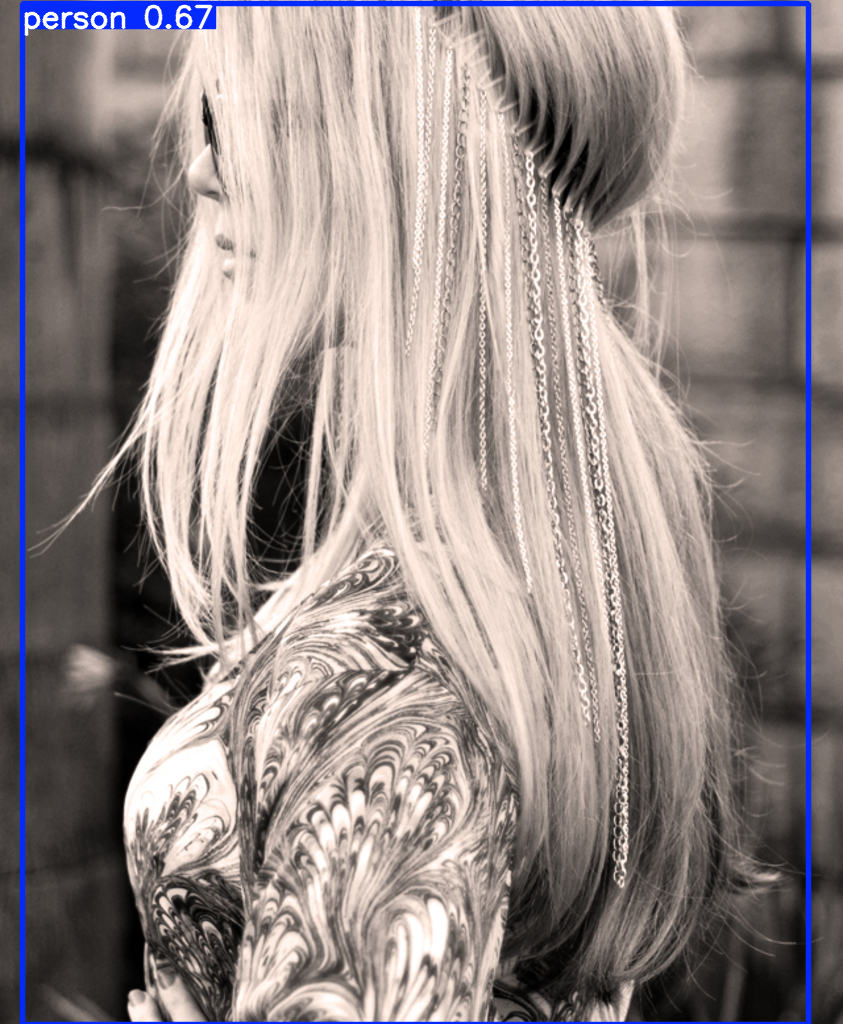

In [ ]:
# Load trained model
model = YOLO("yolov8n.pt")  # Use best model

# Run inference on an image
image_path = "/content/face_dataset/images/b0d578cddb459858.jpg"  # Change to a test image
results = model(image_path)

# Show results
results[0].show()